
# Imaging Demo

How to create visibility from pixel data and make images.

The example uses ``stixpy`` to obtain STIX pixel data and convert these into visibilities and ``xrayvisim``
to make the images.

Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('stixpy').setLevel(logging.WARNING)
logger = logging.getLogger('stixpy')
logger.setLevel(logging.WARNING)
# Remove existing handlers (optional but effective)
logger.handlers.clear()
# Add a simple handler if you still want warnings/errors printed
handler = logging.StreamHandler()
handler.setLevel(logging.WARNING)
logger.addHandler(handler)
logging.getLogger('stixpy').disabled = True

import requests
import urllib.request
from bs4 import BeautifulSoup
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import ConnectionPatch
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import ImageNormalize, SqrtStretch, LogStretch
import sunpy
from sunpy.net import Fido, attrs as a
from sunpy.coordinates import frames, HeliographicStonyhurst, Helioprojective
from sunpy.map import Map, make_fitswcs_header
from sunpy.time import TimeRange
from xrayvision.clean import vis_clean
from xrayvision.imaging import vis_to_image, vis_to_map
# from xrayvision.mem import mem, resistant_mean
import stixpy                                  # This registers the a.stix attrs
from stixpy.calibration.visibility import calibrate_visibility, create_meta_pixels, create_visibility
from stixpy.coordinates.frames import STIXImaging
from stixpy.coordinates.transforms import get_hpc_info
# from stixpy.imaging.em import em
from stixpy.map.stix import STIXMap
from stixpy.product import Product

Read science file as Product



In [2]:
def find_links(url='http://www.python.org'):
    """
    Get all the links in a webpage.
    Source: https://stackoverflow.com/questions/20150184/make-a-list-of-all-the-files-on-a-website
    """
    soup = BeautifulSoup(requests.get(url).text)
    hrefs = []
    for a in soup.find_all('a'):
        hrefs.append(a['href'])
    return hrefs

In [4]:
def extract_timerange(filename):
    # isolate the time part
    time_part = filename.split('_')[3]  # '20260118T000340-20260118T000644'
    
    start_str, end_str = time_part.split('-')
    
    t_start = datetime.strptime(start_str, '%Y%m%dT%H%M%S')
    t_end   = datetime.strptime(end_str,   '%Y%m%dT%H%M%S')
    
    return t_start, t_end


def is_overlap(file_start, file_end, query_start, query_end):
    # overlap condition
    return not (file_end < query_start or file_start > query_end)

In [3]:
start_date       = '2025-10-06'
YEAR, MONTH, DAY = start_date.split('-')
print(YEAR, MONTH, DAY)

# show the links of the CPD SCI files
sci_url = f'https://pub099.cs.technik.fhnw.ch/fits/L1/{YEAR}/{MONTH}/{DAY}/SCI/'
list_sci_links = find_links(url=sci_url)

# show what you've found
for i, link in enumerate(list_sci_links):
    print(i, link)

2025 10 06
0 ?C=N;O=D
1 ?C=M;O=A
2 ?C=S;O=A
3 ?C=D;O=A
4 /fits/L1/2025/10/06/
5 solo_L1_stix-sci-aspect-burst_20251006T020000-20251006T075958_V02_2510031479.fits
6 solo_L1_stix-sci-aspect-burst_20251006T075959-20251006T135958_V02_2510039907.fits
7 solo_L1_stix-sci-aspect-burst_20251006T135959-20251006T195958_V02_2510033243.fits
8 solo_L1_stix-sci-aspect-burst_20251006T175259-20251006T180258_V02_2510069925.fits
9 solo_L1_stix-sci-aspect-burst_20251006T195959-20251006T230003_V02_2510039417.fits
10 solo_L1_stix-sci-aspect-burst_20251006T225959-20251007T045958_V02_2510060820.fits
11 solo_L1_stix-sci-xray-cpd_20251006T000001-20251006T060014_V02_2510067007-51035.fits
12 solo_L1_stix-sci-xray-cpd_20251006T060014-20251006T120002_V02_2510069289-51036.fits
13 solo_L1_stix-sci-xray-cpd_20251006T064534-20251006T065203_V02_2510060607-50683.fits
14 solo_L1_stix-sci-xray-cpd_20251006T065802-20251006T074602_V02_2510067275-50230.fits
15 solo_L1_stix-sci-xray-cpd_20251006T083231-20251006T090411_V02_2510

In [5]:
sci_query_start = datetime(int(YEAR), int(MONTH), int(DAY), 8, 50, 0)
sci_query_end   = datetime(int(YEAR), int(MONTH), int(DAY), 9, 5, 0)

valid_sci_files = []

for link in list_sci_links:
    if not link.endswith('.fits'):
        continue
    
    f_start, f_end = extract_timerange(link)

    if 'cpd' in link:    
        if is_overlap(f_start, f_end, sci_query_start, sci_query_end):
            valid_sci_files.append(link)

print(*valid_sci_files, sep='\n')

solo_L1_stix-sci-xray-cpd_20251006T060014-20251006T120002_V02_2510069289-51036.fits
solo_L1_stix-sci-xray-cpd_20251006T083231-20251006T090411_V02_2510060001-50684.fits


In [6]:
sci_file_idx = 1
cpd_sci =  Product(f'{sci_url}/{valid_sci_files[sci_file_idx]}')
cpd_sci

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x78feaa403290>
    Start: 2025-10-06 08:32:31
    End:   2025-10-06 09:04:11
    Center:2025-10-06 08:48:21
    Duration:0.02198726851851851 days or
           0.5276944444444442 hours or
           31.661666666666655 minutes or
           1899.6999999999994 seconds
    DetectorMasks
    [0...185]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...185]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,_,_,_,_,_,_,_,_,_,_,_,_,_,_]

Read background file as Product



In [7]:
bkg_query_start = datetime(int(YEAR), int(MONTH), int(DAY), 7, 0, 0)
bkg_query_end   = datetime(int(YEAR), int(MONTH), int(DAY), 7, 30, 0)

valid_bkg_files = []

for link in list_sci_links:
    if not link.endswith('.fits'):
        continue
    
    f_start, f_end = extract_timerange(link)

    if 'cpd' in link:    
        if is_overlap(f_start, f_end, bkg_query_start, bkg_query_end):
            valid_bkg_files.append(link)

print(*valid_bkg_files, sep='\n')

solo_L1_stix-sci-xray-cpd_20251006T060014-20251006T120002_V02_2510069289-51036.fits
solo_L1_stix-sci-xray-cpd_20251006T065802-20251006T074602_V02_2510067275-50230.fits


In [8]:
bkg_file_idx = 1
cpd_bkg =  Product(f'{sci_url}/{valid_bkg_files[bkg_file_idx]}')
cpd_bkg

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x79008026d6d0>
    Start: 2025-10-06 06:58:02
    End:   2025-10-06 07:46:02
    Center:2025-10-06 07:22:02
    Duration:0.033333333333333326 days or
           0.7999999999999998 hours or
           47.999999999999986 minutes or
           2879.9999999999995 seconds
    DetectorMasks
    [0]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0]: [['1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1']]

    EnergyEdgeMasks
    [0]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]

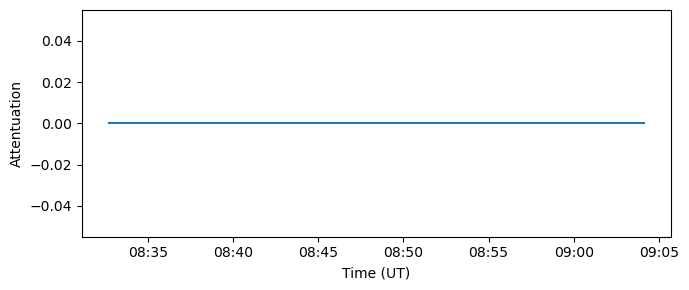

In [9]:
fig = plt.figure(figsize=[7,3])
ax  = fig.add_subplot(111)
ax.plot(cpd_sci.times.datetime, cpd_sci.data['rcr'])
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Attentuation')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.tight_layout()
plt.show()

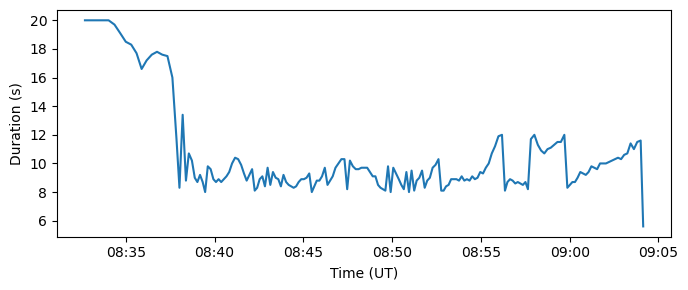

In [10]:
fig = plt.figure(figsize=[7,3])
ax  = fig.add_subplot(111)
ax.plot(cpd_sci.times.datetime, cpd_sci.duration.to_value('s'))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Duration (s)')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.tight_layout()
plt.show()

Set time and energy ranges which will be considered for the science and the background file



In [11]:
energy_dict = {
    '4 - 9 keV':   [ 4,  9],
    '6 - 15 keV':  [ 6, 15],
    '35 - 76 keV': [36, 76],
    '15 - 28 keV': [15, 28]
}

for i, item in enumerate(energy_dict):
    print(i, ':', item, '\t-->', energy_dict[item])

0 : 4 - 9 keV 	--> [4, 9]
1 : 6 - 15 keV 	--> [6, 15]
2 : 35 - 76 keV 	--> [36, 76]
3 : 15 - 28 keV 	--> [15, 28]


In [12]:
time_range_sci = [sci_query_start, sci_query_end]
time_range_bkg = [bkg_query_start, bkg_query_end] # Set this range larger than the actual observation time

xray_band = '6 - 15 keV'
energy_range = energy_dict[xray_band]*u.keV

Create the meta pixel, A, B, C, D for the science and the background data



In [13]:
meta_pixels_sci = create_meta_pixels(
    cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
)

meta_pixels_bkg = create_meta_pixels(
    cpd_bkg, time_range=time_range_bkg, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
)

Perform background subtraction



In [14]:
meta_pixels_bkg_subtracted = {
    **meta_pixels_sci,
    "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
    "abcd_rate_error_kev_cm": np.sqrt(
        meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
    ),
}

Create visibilities from the meta pixels



In [15]:
vis = create_visibility(meta_pixels_bkg_subtracted)

Obtain the necessary ephemeris data create HPC 0,0 coordinate

In [16]:
res = Fido.search(
    a.Time(f'{start_date}T08:50', f'{start_date}T08:55'),
    a.Instrument.stix,
    a.stix.DataType.asp,
    a.stix.DataProduct.asp_ephemeris,
)

print(res)

Results from 1 Provider:

1 Results from the STIXClient:

       Start Time               End Time        Instrument Level DataType  DataProduct  Ver Request ID
----------------------- ----------------------- ---------- ----- -------- ------------- --- ----------
2025-10-06 00:00:00.000 2025-10-06 23:59:59.999       STIX   ANC      ASP asp-ephemeris V02          -




In [17]:
vis_tr = TimeRange(vis.meta["time_range"])
roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
center_hpc = SkyCoord(0 * u.deg, 0 * u.deg, frame=Helioprojective(obstime=vis_tr.center, observer=solo))

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [18]:
vis

Visibilities< 30, [-0.00630848-0.05347613j  0.09433423+0.41136782j -0.88334492-0.53057109j
  0.86097131-0.00399888j -0.02243008+0.17899198j -0.12153564+0.1949611j
 -0.0622317 -0.00376238j -0.23085055-0.15000666j  0.06330101+0.06096366j
  0.04625555-0.02907698j  0.02238237+0.02689553j  0.60349525+0.78415432j
  0.39968357+0.07853988j  0.74616589-0.43981429j  0.03581242-0.11242765j
 -0.0300334 -0.10914034j  0.06438031-0.03516482j -1.27240492-0.00712837j
 -0.48765373+0.27336265j  1.17939275+0.05302233j  0.13538881+0.06736938j
  0.26855701-0.19338669j -0.04642773-0.05240863j -0.38739728+0.00617232j
  0.44294016+0.01844401j -0.04941439+0.1755969j   0.00203226-0.05032748j
  0.19178273+0.01931351j -0.20562961+0.20870749j -1.41785875+0.20748463j] ct / (keV s cm2)>

In [19]:
vis.meta["time_range"]

<Time object: scale='utc' format='isot' value=['2025-10-06T08:49:58.800' '2025-10-06T09:04:11.200']>

Calibrate the visibilities

If not given will default to sun center flare location



In [20]:
cal_vis = calibrate_visibility(vis, flare_location=center_hpc)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Selected detectors 10 to 7



In [21]:
# order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....
isc_10_7 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28]
idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_7)).ravel()

Slice the visibilities to detectors 10 - 7



In [22]:
vis10_7 = cal_vis[idx]

Set up image parameters



In [23]:
imsize = [512, 512] * u.pixel  # number of pixels of the map to reconstruct
pixel = [10, 10] * u.arcsec / u.pixel  # pixel size in arcsec

Make a full disk back projection (inverse transform) map



In [24]:
bp_image = vis_to_image(vis10_7, imsize, pixel_size=pixel)

Obtain the necessary ephemeris data



In [25]:
vis_tr = TimeRange(vis.meta["time_range"])
roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
coord_stix = center_hpc.transform_to(STIXImaging(obstime=vis_tr.start, obstime_end=vis_tr.end, observer=solo))
header = make_fitswcs_header(
    bp_image, coord_stix, telescope="STIX", observatory="Solar Orbiter", scale=[10, 10] * u.arcsec / u.pix
)
fd_bp_map = Map((bp_image, header))

Convert the coordinates and make a map in Helioprojective and rotate so "North" is "up"
Center of STIX pointing in HPC



In [26]:
header_hp = make_fitswcs_header(
    bp_image, center_hpc, scale=[10,10]*u.arcsec / u.pix, rotation_angle=90 * u.deg + roll
)
hp_map = Map((bp_image, header_hp))
hp_map_rotated = hp_map.rotate()

Plot the both maps



Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

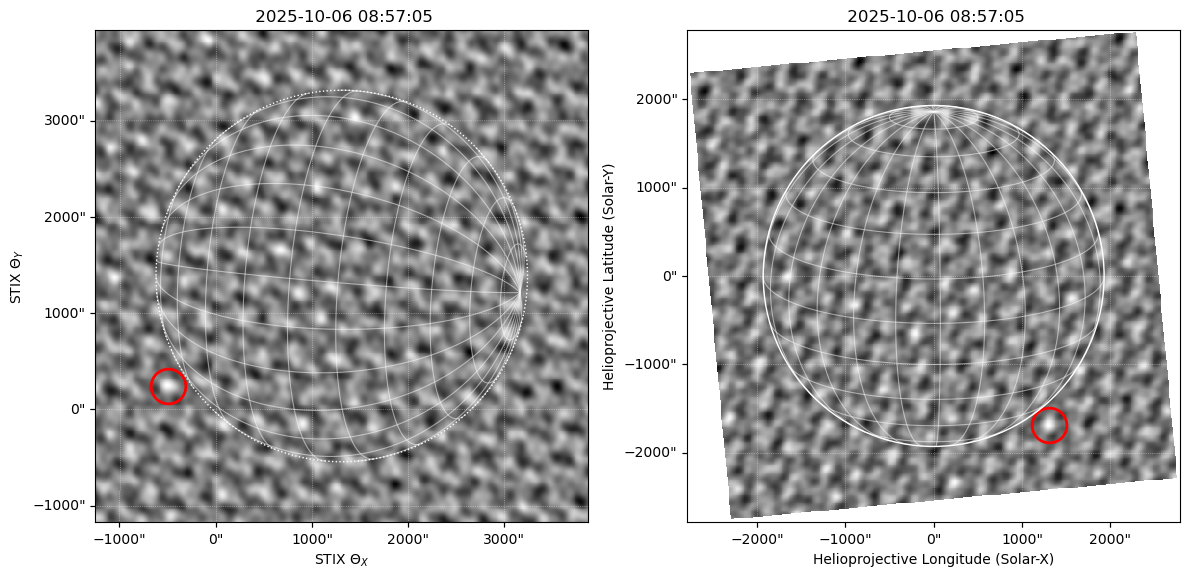

In [27]:
fig = plt.figure(layout="constrained", figsize=[12,6])
ax = fig.subplot_mosaic(
    [["stix", "hpc"]], per_subplot_kw={"stix": {"projection": fd_bp_map}, "hpc": {"projection": hp_map_rotated}}
)
fd_bp_map.plot(axes=ax["stix"])
fd_bp_map.draw_limb()
fd_bp_map.draw_grid()

hp_map_rotated.plot(axes=ax["hpc"])
hp_map_rotated.draw_limb()
hp_map_rotated.draw_grid()

"""
Estimate the flare location and plot on top of back projection map.
Note the coordinates are automatically converted from the STIXImaging to Helioprojective.
"""
max_pixel = np.argwhere(fd_bp_map.data == fd_bp_map.data.max()).ravel() * u.pixel
# because WCS axes and array are reversed
max_stix = fd_bp_map.pixel_to_world(max_pixel[1], max_pixel[0])

ax["stix"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
ax["hpc"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
fig.tight_layout()
plt.show()

Use estimated flare location to create more accurate visibilities



In [28]:
meta_pixels_sci = create_meta_pixels(
    cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=max_stix, no_shadowing=True
)

meta_pixels_bkg_subtracted = {
    **meta_pixels_sci,
    "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
    "abcd_rate_error_kev_cm": np.sqrt(
        meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
    ),
}

vis = create_visibility(meta_pixels_bkg_subtracted)
cal_vis = calibrate_visibility(vis, flare_location=max_stix)

Selected detectors 10 to 3
order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....



In [29]:
isc_10_3 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28, 15, 27, 31, 6, 30, 2, 25, 5, 23, 7, 29, 1]
idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_3)).ravel()

Create an ``xrayvsion`` visibility object



In [30]:
cal_vis.meta['offset'] = max_stix
vis10_3 = cal_vis[idx]

Set up image parameters



In [31]:
imsize = [129, 129]*u.pixel        # number of pixels of the map to reconstruct
pixel = [2, 2]*u.arcsec / u.pixel  # pixel size in arcsec

Create a clean image using the clean algorithm `vis_clean`

In [32]:
niter = 200  # number of iterations
gain = 0.1   # gain used in each clean iteration
beam_width = 20.0 * u.arcsec
clean_map, model_map, resid_map = vis_clean(
    vis10_3, imsize, pixel_size=pixel, gain=gain, niter=niter, clean_beam_width=20 * u.arcsec
)

2026-05-14T16:18:22Z INFO xrayvision.clean 124: Iter: 0, strength: 0.9304792912646178, location: (np.int64(70), np.int64(57))
2026-05-14 16:18:22 - xrayvision.clean - INFO: Iter: 0, strength: 0.9304792912646178, location: (np.int64(70), np.int64(57))
2026-05-14T16:18:22Z INFO xrayvision.clean 124: Iter: 25, strength: 0.4189156940367702, location: (np.int64(63), np.int64(96))
2026-05-14 16:18:22 - xrayvision.clean - INFO: Iter: 25, strength: 0.4189156940367702, location: (np.int64(63), np.int64(96))
2026-05-14T16:18:22Z INFO xrayvision.clean 145: Largest residual negative
2026-05-14 16:18:22 - xrayvision.clean - INFO: Largest residual negative


Create a sunpy map for the clean image in Helioprojective



In [33]:
header = make_fitswcs_header(
    clean_map.data,
    max_stix.transform_to(Helioprojective(obstime=vis_tr.center, observer=solo)),
    telescope='STIX',
    observatory='Solar Orbiter',
    scale=pixel,
    rotation_angle=90*u.deg + roll,
)

clean_map = Map((clean_map.data, header)).rotate()
# vmax = clean_map.data.max()

In [ ]:
# Plot the Clean method
fig = plt.figure(figsize=[5,5])
ax  = fig.add_subplot(111, projection=clean_map)
clean_map.plot(axes=ax, cmap='RdYlBu_r')

with sunpy.coordinates.frames.Helioprojective.assume_spherical_screen(clean_map.observer_coordinate):
    # c0 = clean_map.draw_contours(levels=(70)*u.percent, autoalign=True, fill=True, colors='black', alpha=0.3)
    c0 = clean_map.draw_contours(levels=(70)*u.percent, axes=ax, autoalign=True, colors='black')

# find the maxima pixel locations for the clean stix map
clean_map_maxloc = np.unravel_index(np.nanargmax(clean_map.data), clean_map.data.shape)*u.pixel
# convert to sky coordinates
maxcoords = clean_map.pixel_to_world(clean_map_maxloc[1], clean_map_maxloc[0])
# plot the maxima centroids
ax.plot_coord(maxcoords, 'wx', fillstyle='none', markersize=5, linewidth=5, color='black')

ax.grid(False)
fig.tight_layout()
plt.show()

In [ ]:
t = clean_map.meta['date-obs']

dt = datetime.fromisoformat(t)
dt_new = dt + timedelta(seconds=12)

print(t, dt_new.isoformat())

In [ ]:
aia_result = Fido.search(a.Time(t, dt_new),
                         a.Instrument('AIA'),
                         a.Wavelength(193*u.angstrom),
                         a.Sample(12*u.second)
                        )
aia_files = Fido.fetch(aia_result, site='NSO')

In [ ]:
aia_files

In [ ]:
aia = sunpy.map.Map(aia_files[0])
# aia.plot_settings['norm'] = ImageNormalize(vmin=50, vmax=3e3, stretch=SqrtStretch())
# aia.plot_settings['norm'] = ImageNormalize(vmin=-1e2, vmax=1e4, stretch=LogStretch())

fig = plt.figure(figsize=[7,7])
ax = fig.add_subplot(projection=aia)
m = aia.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)
fig.colorbar(m, ax=ax, pad=0.01, shrink=0.8, label=aia.meta['pixlunit'])
ax.grid(False)
fig.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=[7,7])
ax  = fig.add_subplot(111, projection=aia)
aia.plot(axes=ax, clip_interval=(1, 99.9)*u.percent, cmap='Greys')

with frames.Helioprojective.assume_spherical_screen(aia.observer_coordinate):
    clean_map_proj = clean_map.reproject_to(aia.wcs)

clean_map_proj.draw_contours(axes=ax, levels=np.arange(70, 100, 10)*u.percent, autoalign=True, colors='red')

ax.grid(False)
fig.tight_layout()
plt.show()

In [40]:
# fig = plt.figure(figsize=[7,7])
# ax = fig.add_subplot(111, projection=aia)
# aia.plot(axes=ax, cmap='Greys')

# with frames.Helioprojective.assume_spherical_screen(aia.observer_coordinate):
#     clean_map_proj = clean_map.reproject_to(aia.wcs)
#     clean_map_proj.draw_contours(axes=ax, levels=np.arange(70, 100, 10)*u.percent, autoalign=True, colors='red')

# ax.grid(False)
# fig.tight_layout()
# plt.show()

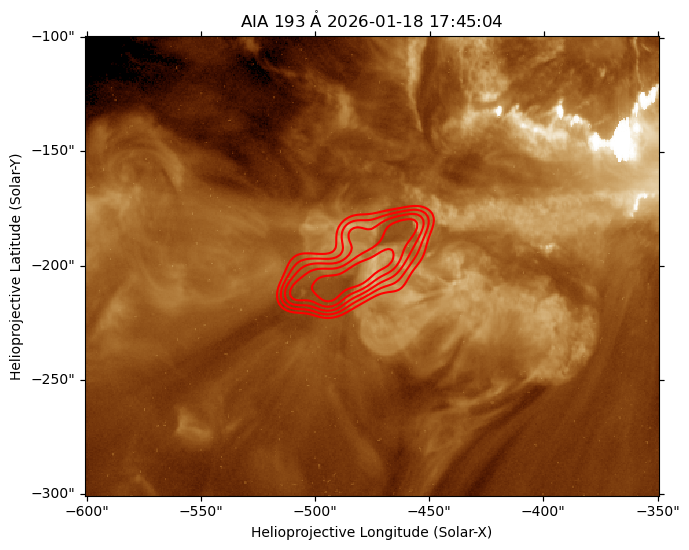

In [41]:
top_right   = SkyCoord(-350*u.arcsec, -100*u.arcsec, frame=aia.coordinate_frame)
bottom_left = SkyCoord(-600*u.arcsec, -300*u.arcsec, frame=aia.coordinate_frame)
aia_sub = aia.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=[7,7])
ax = fig.add_subplot(projection=aia_sub)
aia_sub.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)

with frames.Helioprojective.assume_spherical_screen(aia_sub.observer_coordinate):
    clean_map_proj = clean_map.reproject_to(aia_sub.wcs)

# clean_map_proj.draw_contours(levels=np.arange(70, 100, 10)*u.percent, axes=ax, autoalign=True, colors='red')/
clean_map_proj.draw_contours(levels=[50,60,70,80,90]*u.percent, axes=ax, autoalign=True, colors='red')

ax.grid(False)
fig.tight_layout()
plt.show()

In [42]:
np.arange(70, 100, 10)

array([70, 80, 90])

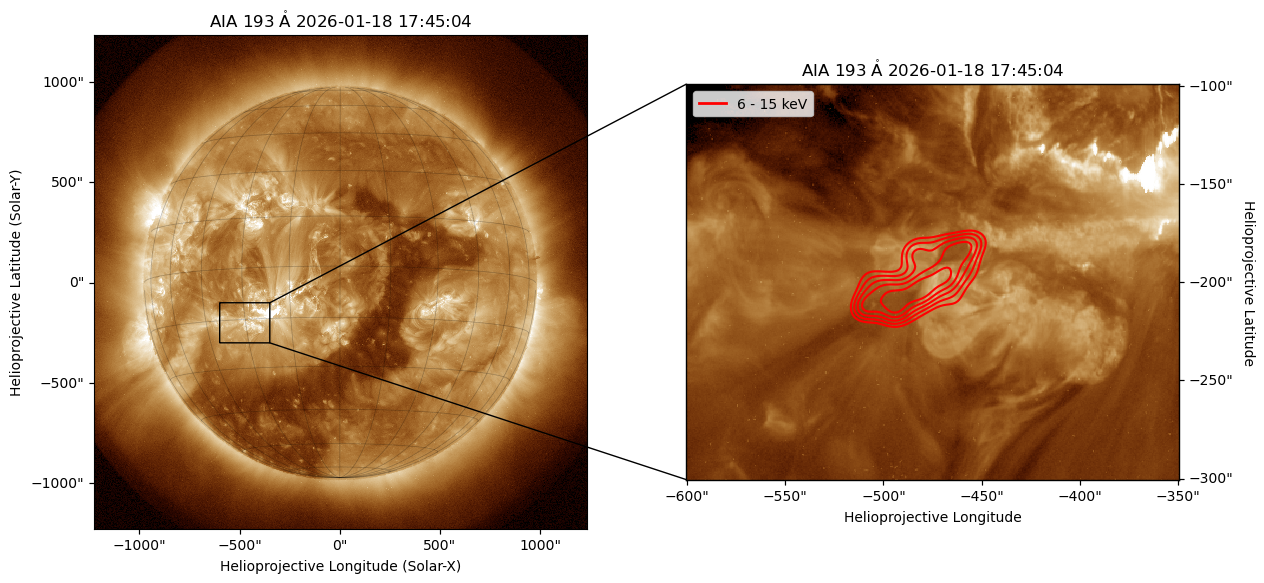

In [43]:
#### The first stage is plotting the full-disk AIA 193 Ao
fig = plt.figure(figsize=[14,7])

ax1 = fig.add_subplot(121, projection=aia)
# aia.plot(axes=ax1, cmap='Greys')
aia.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
aia.draw_grid(axes=ax1, color='black', alpha=0.25, lw=0.5)
ax1.grid(b=False)

# draw the rectangle around the region we plan to showcase in the cutout image
aia.draw_quadrangle(bottom_left, top_right=top_right, edgecolor='black', lw=1)

#### The second stage is plotting the zoomed-in map
ax2 = fig.add_subplot(122, projection=aia_sub)
aia_sub.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
ax2.grid(False)

with frames.Helioprojective.assume_spherical_screen(aia_sub.observer_coordinate):
    clean_map_proj = clean_map.reproject_to(aia_sub.wcs)
clean_map_proj.draw_contours(levels=[50,60,70,80,90]*u.percent, axes=ax2, autoalign=True, colors='red')

ax2.plot([], [], color='red', lw=2, label=xray_band)
ax2.legend(loc='upper left')

# clean up the axis labels and ticks
lon, lat = ax2.coords[0], ax2.coords[1]
lon.frame.set_linewidth(1)
lat.frame.set_linewidth(1)
lon.set_axislabel('Helioprojective Longitude',)
lon.set_ticks_position('b')
lat.set_axislabel('Helioprojective Latitude',)
lat.set_axislabel_position('r')
lat.set_ticks_position('r')
lat.set_ticklabel_position('r')

# we add two lines that will connect the two images as well as a colorbar
xpix, ypix = aia.world_to_pixel(top_right)
con1 = ConnectionPatch(
    (0,1), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, 
    arrowstyle='-', color='black', lw=1)

xpix, ypix = aia.world_to_pixel(SkyCoord(top_right.Tx, bottom_left.Ty, frame=aia.coordinate_frame))
con2 = ConnectionPatch(
    (0,0), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, arrowstyle='-', color='black', lw=1)

ax2.add_artist(con1)
ax2.add_artist(con2)
plt.show()

In [44]:
energy_dict = {
    '4 - 9 keV':   [ 4,  9],
    '6 - 15 keV':  [ 6, 15],
    '15 - 28 keV': [15, 28],
    '35 - 76 keV': [36, 76]
}

for i, item in enumerate(energy_dict):
    print(i, ':', item, '\t-->', energy_dict[item])

0 : 4 - 9 keV 	--> [4, 9]
1 : 6 - 15 keV 	--> [6, 15]
2 : 35 - 76 keV 	--> [36, 76]
3 : 15 - 28 keV 	--> [15, 28]


In [48]:
clean_stix_maps = {}

# Define the energy range for STIX (in keV)
for item in energy_dict:
    energy_range = energy_dict[item]*u.keV
    
    # Create the meta pixel, A, B, C, D for the science and the background data
    meta_pixels_sci = create_meta_pixels(
        cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=[0,0]*u.arcsec, no_shadowing=True
    )
    meta_pixels_bkg = create_meta_pixels(
        cpd_bkg, time_range=time_range_bkg, energy_range=energy_range, flare_location=[0,0]*u.arcsec, no_shadowing=True
    )
    
    # Perform background subtraction
    meta_pixels_bkg_subtracted = {
        **meta_pixels_sci,
        'abcd_rate_kev_cm': meta_pixels_sci['abcd_rate_kev_cm'] - meta_pixels_bkg['abcd_rate_kev_cm'],
        'abcd_rate_error_kev_cm': np.sqrt(
            meta_pixels_sci['abcd_rate_error_kev_cm']**2 + meta_pixels_bkg['abcd_rate_error_kev_cm']**2
        )
    }
    
    # Create visibilities from the meta pixels
    vis = create_visibility(meta_pixels_bkg_subtracted)
    
    # Create the time range for the visibility data and get the HPC coords of the observer (SolO) and the centre of the Sun in Helioprojective coords
    vis_tr = TimeRange(vis.meta['time_range'])
    roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
    solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type='cartesian')
    center_hpc = SkyCoord(0*u.deg, 0*u.deg, frame=Helioprojective(obstime=vis_tr.center, observer=solo))
    
    # Calibrate the visibilities: If not given will default to sun center flare location
    # order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....
    isc_10_7 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28]
    idx = np.argwhere(np.isin(cal_vis.meta['isc'], isc_10_7)).ravel()
    
    # Slice the visibilities to detectors 10 - 7
    vis10_7 = cal_vis[idx]
    
    # Set up image parameters
    imsize = [512, 512]*u.pixel           # number of pixels of the map to reconstruct
    pixel  = [10, 10]*u.arcsec / u.pixel  # pixel size in arcsec
    
    # Make a full disk back projection (inverse transform) map
    bp_image = vis_to_image(vis10_7, imsize, pixel_size=pixel)
    
    # Obtain the necessary ephemeris data
    vis_tr = TimeRange(vis.meta['time_range'])
    roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
    solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type='cartesian')
    coord_stix = center_hpc.transform_to(STIXImaging(obstime=vis_tr.start, obstime_end=vis_tr.end, observer=solo))
    header = make_fitswcs_header(
        bp_image, coord_stix, telescope='STIX', observatory='Solar Orbiter', scale=[10,10]*u.arcsec / u.pix
    )
    fd_bp_map = Map((bp_image, header))
    
    # Convert the coordinates and make a map in Helioprojective and rotate so "North" is "up" Center of STIX pointing in HPC
    header_hp = make_fitswcs_header(
        bp_image, center_hpc, scale=[10,10]*u.arcsec / u.pix, rotation_angle=90*u.deg + roll
    )
    hp_map = Map((bp_image, header_hp))
    hp_map_rotated = hp_map.rotate()
    
    # Use estimated flare location to create more accurate visibilities
    meta_pixels_sci = create_meta_pixels(
        cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=max_stix, no_shadowing=True
    )
    
    meta_pixels_bkg_subtracted = {
        **meta_pixels_sci,
        "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
        "abcd_rate_error_kev_cm": np.sqrt(
            meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
        ),
    }
    
    vis = create_visibility(meta_pixels_bkg_subtracted)
    cal_vis = calibrate_visibility(vis, flare_location=max_stix)
    
    # Selected detectors 10 to 3 order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c, ...
    isc_10_3 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28, 15, 27, 31, 6, 30, 2, 25, 5, 23, 7, 29, 1]
    idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_3)).ravel()
    
    # Create an xrayvsion visibility object
    cal_vis.meta['offset'] = max_stix
    vis10_3 = cal_vis[idx]
    
    # Set up image parameters
    imsize = [129, 129]*u.pixel        # number of pixels of the map to reconstruct
    pixel = [2, 2]*u.arcsec / u.pixel  # pixel size in arcsec
    
    # Create a clean image using the clean algorithm vis_clean
    niter = 200  # number of iterations
    gain = 0.1   # gain used in each clean iteration
    beam_width = 20.0 * u.arcsec
    clean_map, model_map, resid_map = vis_clean(
        vis10_3, imsize, pixel_size=pixel, gain=gain, niter=niter, clean_beam_width=20 * u.arcsec
    )
    
    # Create a sunpy map for the clean image in Helioprojective
    header = make_fitswcs_header(
        clean_map.data,
        max_stix.transform_to(Helioprojective(obstime=vis_tr.center, observer=solo)),
        telescope='STIX',
        observatory='Solar Orbiter',
        scale=pixel,
        rotation_angle=90*u.deg + roll,
    )
    clean_map = Map((clean_map.data, header)).rotate()
    clean_stix_maps[item] = clean_map
    
    print(f'STIX cannel {item} keV is cleaned and ready')

2026-04-18T00:31:49Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:31:49 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:31:49Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:31:49 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:31:49Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:31:49 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:31:54Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:31:54 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:31:54Z INFO xrayvision.clean 124: Iter: 0, strength: 1672.5563

Max iterations reached


2026-04-18T00:31:56Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:31:56 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec


STIX cannel 4 - 9 keV keV is cleaned and ready


2026-04-18T00:32:05Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:05 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:05Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:05 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:05Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:05 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:10Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:10 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:10Z INFO xrayvision.clean 124: Iter: 0, strength: 998.38710

STIX cannel 6 - 15 keV keV is cleaned and ready


2026-04-18T00:32:21Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:21 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:21Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:21 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:21Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:21 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:26Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:26 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:26Z INFO xrayvision.clean 124: Iter: 0, strength: 0.1505607

STIX cannel 35 - 76 keV keV is cleaned and ready


2026-04-18T00:32:37Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:37 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:37Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:37 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:37Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:37 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:42Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18 00:32:42 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-18T00:32:42Z INFO xrayvision.clean 124: Iter: 0, strength: 10.693784

STIX cannel 15 - 28 keV keV is cleaned and ready


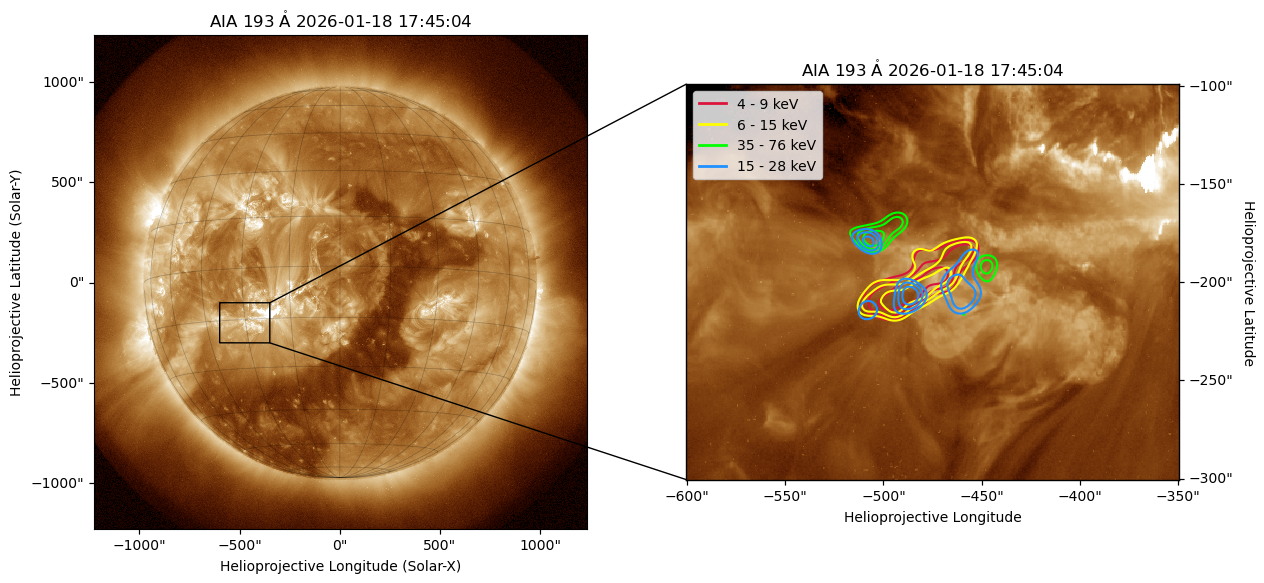

In [53]:
#### The first stage is plotting the full-disk AIA 193 Ao
fig = plt.figure(figsize=[14,7])

ax1 = fig.add_subplot(121, projection=aia)
# aia.plot(axes=ax1, cmap='Greys')
aia.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
aia.draw_grid(axes=ax1, color='black', alpha=0.25, lw=0.5)
ax1.grid(b=False)

# draw the rectangle around the region we plan to showcase in the cutout image
aia.draw_quadrangle(bottom_left, top_right=top_right, edgecolor='black', lw=1)

#### The second stage is plotting the zoomed-in map
ax2 = fig.add_subplot(122, projection=aia_sub)
aia_sub.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
ax2.grid(False)

colors = ['crimson', 'yellow', 'lime', 'dodgerblue']
for stix_map, color in zip(clean_stix_maps, colors):
    clean_map = clean_stix_maps[stix_map]
    with frames.Helioprojective.assume_spherical_screen(aia_sub.observer_coordinate):
        clean_map_proj = clean_map.reproject_to(aia_sub.wcs)
    
    clean_map_proj.draw_contours(levels=[70,80,90]*u.percent, axes=ax2, autoalign=True, colors=color)
    ax2.plot([], [], color=color, lw=2, label=stix_map)

ax2.legend(loc='upper left')

# clean up the axis labels and ticks
lon, lat = ax2.coords[0], ax2.coords[1]
lon.frame.set_linewidth(1)
lat.frame.set_linewidth(1)
lon.set_axislabel('Helioprojective Longitude',)
lon.set_ticks_position('b')
lat.set_axislabel('Helioprojective Latitude',)
lat.set_axislabel_position('r')
lat.set_ticks_position('r')
lat.set_ticklabel_position('r')

# we add two lines that will connect the two images as well as a colorbar
xpix, ypix = aia.world_to_pixel(top_right)
con1 = ConnectionPatch(
    (0,1), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, 
    arrowstyle='-', color='black', lw=1)

xpix, ypix = aia.world_to_pixel(SkyCoord(top_right.Tx, bottom_left.Ty, frame=aia.coordinate_frame))
con2 = ConnectionPatch(
    (0,0), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, arrowstyle='-', color='black', lw=1)

ax2.add_artist(con1)
ax2.add_artist(con2)
plt.show()

In [57]:
import scipy.io as io
trin = io.readsav('/home/mnedal/data/aia_tresp_en.dat')
print(f"Number of channels in response file: {len(trin['tr'])}")
# If it says 6, it's almost certainly [94, 131, 171, 193, 211, 335]

Number of channels in response file: 6


In [59]:
trin['channels']

array([b'A94', b'A131', b'A171', b'A193', b'A211', b'A335'], dtype=object)